# Elasto-dynamics in 3D: Explicit Central Difference Integration

Elastic wave propagation in a 3D bar under a step axial load. A compressive P-wave is launched from the free end (x = L), travels to the clamped end (x = 0), reflects, and returns.

The leap-frog (central difference) scheme reads:

$$u_{n+1} = u_n + \Delta t\, v_{n+1/2}$$

$$a_{n+1} = M^{-1}\bigl(f_\mathrm{ext} - f_\mathrm{int}(u_{n+1})\bigr)$$

$$v_{n+3/2} = v_{n+1/2} + \Delta t\, a_{n+1}$$

The scheme is conditionally stable for $\Delta t \leq h_\mathrm{min} / c_p$, where $c_p = \sqrt{(\lambda + 2\mu)/\rho}$ is the dilatational wave speed.
Because each step has fixed cost (no inner Newton iteration), the entire time loop is compiled with `jax.lax.scan`.

In [1]:
import time
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from jax_autovmap import autovmap

from tatva import Mesh, Operator, element

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", "cpu")

In [2]:
# [collapse: code] Structured tetrahedral mesh for a rectangular bar


def create_bar_mesh(
    lengths: tuple[float, float, float],
    nb_elems: tuple[int, int, int],
) -> Mesh:
    """Structured tet mesh for a bar along the x-axis.

    Bar occupies: x in [0, L], y in [-W/2, W/2], z in [-H/2, H/2].
    Each hexahedral cell is subdivided into 6 tetrahedra sharing the body
    diagonal, following the same pattern as the hyperelastic_3d example.
    """
    x_length, y_length, z_length = lengths
    nx, ny, nz = nb_elems

    x_rng = np.linspace(0.0, x_length, nx + 1)
    y_rng = np.linspace(-y_length / 2.0, y_length / 2.0, ny + 1)
    z_rng = np.linspace(-z_length / 2.0, z_length / 2.0, nz + 1)

    # Node global index: ix + iy*(nx+1) + iz*(nx+1)*(ny+1)
    Z, Y, X = np.meshgrid(z_rng, y_rng, x_rng, indexing="ij")
    nodes = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)

    stride_x = 1
    stride_y = nx + 1
    stride_z = (nx + 1) * (ny + 1)

    k_idx, j_idx, i_idx = np.meshgrid(
        np.arange(nz), np.arange(ny), np.arange(nx), indexing="ij"
    )
    n0 = (i_idx * stride_x + j_idx * stride_y + k_idx * stride_z).ravel()
    n1 = n0 + stride_x
    n2 = n0 + stride_y
    n3 = n2 + stride_x
    n4 = n0 + stride_z
    n5 = n4 + stride_x
    n6 = n4 + stride_y
    n7 = n6 + stride_x

    tets = np.vstack(
        [
            np.stack([n0, n1, n3, n7], axis=1),
            np.stack([n0, n1, n7, n5], axis=1),
            np.stack([n0, n5, n7, n4], axis=1),
            np.stack([n0, n3, n2, n7], axis=1),
            np.stack([n0, n2, n6, n7], axis=1),
            np.stack([n0, n6, n4, n7], axis=1),
        ]
    )
    return Mesh(coords=jnp.array(nodes), elements=jnp.array(tets))

Now, we define material parameters and compute the wave-speeds for the considered material properties.

In [3]:
class Material(NamedTuple):
    mu: float
    lmbda: float
    rho: float

    @classmethod
    def from_young_poisson(cls, E: float, nu: float, rho: float) -> "Material":
        mu = E / (2.0 * (1.0 + nu))
        lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
        return cls(mu=mu, lmbda=lmbda, rho=rho)


mat = Material.from_young_poisson(E=200.0, nu=0.3, rho=1.0)

# Theoretical wave speeds
c_p = float(jnp.sqrt((mat.lmbda + 2.0 * mat.mu) / mat.rho))  # P-wave (dilatational)
c_s = float(jnp.sqrt(mat.mu / mat.rho))  # S-wave (shear)
print(f"P-wave speed: {c_p:.3f}   S-wave speed: {c_s:.3f}")

P-wave speed: 16.408   S-wave speed: 8.771


In [4]:
L, W, H = 10.0, 1.0, 1.0
nx, ny, nz = 40, 3, 3

mesh = create_bar_mesh((L, W, H), (nx, ny, nz))
op = Operator(mesh, element.Tetrahedron4())

n_dofs_per_node = 3
n_nodes = mesh.coords.shape[0]
n_dofs = n_nodes * n_dofs_per_node
print(f"Nodes: {n_nodes}   DOFs: {n_dofs}   Elements: {mesh.elements.shape[0]}")

Nodes: 656   DOFs: 1968   Elements: 2160


## Computing Lumped mass matrix

Lumped mass matrix assembled via AD of the integrated density field. `jacrev` of a scalar integral w.r.t. nodal density gives the row-sum nodal masses.


In [6]:
mass_nodal = jax.jacrev(lambda rho_field: op.integrate(rho_field))(
    jnp.ones(n_nodes) * mat.rho
) 
M_flat = jnp.repeat(mass_nodal, n_dofs_per_node)  

print(
    f"Total mass: {float(jnp.sum(mass_nodal)):.4f}   Expected: {mat.rho * L * W * H:.4f}"
)

Total mass: 10.0000   Expected: 10.0000


## Dirichlet BC 

We assume that the bar is clamped at the left face (x = 0). We apply uniform axial step traction at the right face (x = L), applied at t = 0.


In [8]:
tol = 1e-10
fixed_nodes = jnp.where(jnp.isclose(mesh.coords[:, 0], 0.0, atol=tol))[0]
load_nodes = jnp.where(jnp.isclose(mesh.coords[:, 0], L, atol=tol))[0]

fixed_dofs = jnp.concatenate(
    [
        fixed_nodes * 3,
        fixed_nodes * 3 + 1,
        fixed_nodes * 3 + 2,
    ]
)


The resultant axial force is distributed uniformly over the face nodes. We chose the magnitude o that the peak strain (~$\sigma/E$) stays within the linear regime.


In [9]:
total_force = 5.0
f_ext = jnp.zeros(n_dofs).at[load_nodes * 3].set(total_force / load_nodes.shape[0])

## CFL stability condition 

$$dt < h_\mathrm{min} / c_p$$

We compute $h_\mathrm{min}$ as the shortest edge length over all tetrahedra. And a safety factor of 0.5 to ensure stability.


In [10]:
elem_coords = mesh.coords[mesh.elements]
edge_vecs = jnp.concatenate(
    [
        elem_coords[:, 1] - elem_coords[:, 0],
        elem_coords[:, 2] - elem_coords[:, 0],
        elem_coords[:, 3] - elem_coords[:, 0],
        elem_coords[:, 2] - elem_coords[:, 1],
        elem_coords[:, 3] - elem_coords[:, 1],
        elem_coords[:, 3] - elem_coords[:, 2],
    ],
    axis=0,
)  
h_min = float(jnp.min(jnp.linalg.norm(edge_vecs, axis=1)))

cfl_safety = 0.5
dt = cfl_safety * h_min / c_p

We simulate 3 full round trips of the P-wave (6 one-way traversals). To this end the total number of steps are calculated below based on the length of the bar and the $P-$wave speed.

In [11]:
T_wave = L / c_p  # one-way travel time
n_steps = int(np.ceil(6.0 * T_wave / dt))
save_every = max(1, n_steps // 200)  # store ~200 frames
n_saves = n_steps // save_every

print(
    f"h_min: {h_min:.4f}   dt: {dt:.5f}   n_steps: {n_steps}   "
    f"n_saves: {n_saves}   T_wave: {T_wave:.3f}"
)

h_min: 0.2500   dt: 0.00762   n_steps: 481   n_saves: 240   T_wave: 0.609


# Linear elastic strain energy and internal force 

Now we define the functions to compute the total strain energy of the bar and from it we compute the internal force vector using AD. The strain energy is given as 

$$ \Psi(\boldsymbol{u}) = \int \dfrac{1}{2}\sigma:\epsilon~\mathrm{d}\Omega $$

and the internal force vector is given as 

$$ \boldsymbol{f}_\mathrm{int} = \dfrac{\partial \Psi(\boldsymbol{{u}})}{\partial \boldsymbol{u}} $$

In [12]:

@autovmap(grad_u=2, mu=0, lmbda=0)
def strain_energy_density(grad_u, mu, lmbda):
    eps = 0.5 * (grad_u + grad_u.T)
    return mu * jnp.einsum("ij,ij->", eps, eps) + 0.5 * lmbda * jnp.trace(eps) ** 2


def _strain_energy(u_flat: jnp.ndarray) -> jnp.ndarray:
    u = u_flat.reshape(-1, n_dofs_per_node)
    psi = strain_energy_density(op.grad(u), mat.mu, mat.lmbda)
    return op.integrate(psi)


# Standalone JIT-compiled versions for use outside of lax.scan
strain_energy_jit = jax.jit(_strain_energy)
internal_force_jit = jax.jit(jax.grad(_strain_energy))

## Leap-frog time stepping via `jax.lax.scan`

Using `lax.scan` (rather than a Python for loop) is the natural choice for explicit integrators: each step has identical, fixed cost, so the entire loop compiles to a single XLA program with no Python overhead per step.




In [13]:
# State: (u_n, v_{n+1/2})

def _step(carry: tuple, _: None) -> tuple:
    u, v_half = carry
    # Update positions and enforce Dirichlet BCs
    u_new = (u + dt * v_half).at[fixed_dofs].set(0.0)
    # Compute acceleration: a = (f_ext - f_int) / M
    f_int = jax.grad(_strain_energy)(u_new)
    a = ((f_ext - f_int) / M_flat).at[fixed_dofs].set(0.0)
    # Update staggered velocities
    v_half_new = (v_half + dt * a).at[fixed_dofs].set(0.0)
    return (u_new, v_half_new), None


def _save_step(carry: tuple, _: None) -> tuple:
    """Advance save_every steps then collect observables."""
    (u, v_half), _ = jax.lax.scan(_step, carry, None, length=save_every)
    ke = 0.5 * jnp.sum(M_flat * v_half**2)
    pe = _strain_energy(u)
    # Mean axial displacement at the loaded (free) face
    tip_ux = jnp.mean(u.reshape(-1, n_dofs_per_node)[load_nodes, 0])
    return (u, v_half), (u, ke, pe, tip_ux)


Leap-frog initialization: $v_{1/2} = v_0 + (dt/2) * a_0$. At rest (u=0, v=0): $f_\mathrm{int}(u=0) = 0$, so $a_0 = f_\mathrm{ext} / M$

In [14]:
u0 = jnp.zeros(n_dofs)
a0 = (f_ext / M_flat).at[fixed_dofs].set(0.0)
v_half_0 = (0.5 * dt * a0).at[fixed_dofs].set(0.0)

In [ ]:
t_start = time.time()

(u_final, _), (u_history, ke_history, pe_history, tip_history) = jax.lax.scan(
    _save_step, (u0, v_half_0), None, length=n_saves
)
jax.block_until_ready(u_history)

t_end = time.time()
print(f"Done in {t_end - t_start:.2f}s   u_history shape: {u_history.shape}")

# Move to host
u_history = np.array(u_history)  # (n_saves, n_dofs)
ke_history = np.array(ke_history)  # (n_saves,)
pe_history = np.array(pe_history)  # (n_saves,)
tip_history = np.array(tip_history)
times = np.arange(n_saves) * save_every * dt

Compiling and running explicit dynamics simulation...
Done in 0.84s   u_history shape: (240, 1968)


## Energy balance and tip displacement plots.

For a constant external force, energy conservation reads: $KE(t) + PE(t) = W_\mathrm{ext}(t)$  where $W_\mathrm{ext} = f_\mathrm{ext} \cdot u$. The leap-frog scheme preserves a modified energy, so the residual $KE + PE - W_\mathrm{ext}$  should remain close to zero throughout.


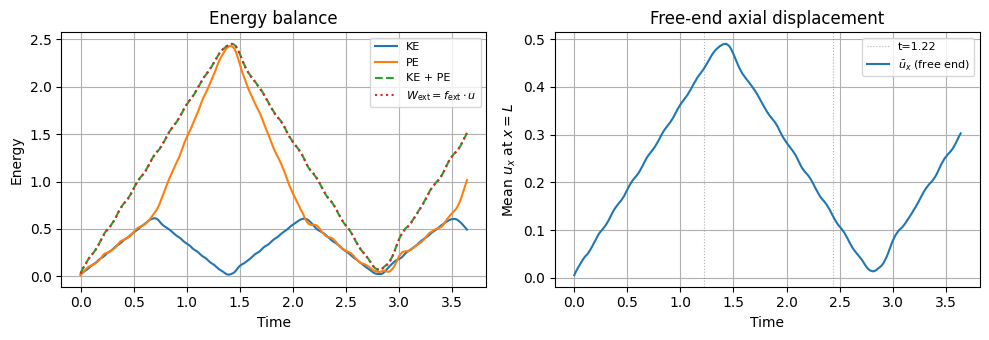

In [16]:

f_ext_np = np.array(f_ext)
w_ext = np.einsum("j,ij->i", f_ext_np, u_history)  # (n_saves,)
te = ke_history + pe_history

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.plot(times, ke_history, label="KE")
ax.plot(times, pe_history, label="PE")
ax.plot(times, te, label="KE + PE", ls="--")
ax.plot(times, w_ext, label=r"$W_\mathrm{ext} = f_\mathrm{ext} \cdot u$", ls=":")
ax.set(xlabel="Time", ylabel="Energy", title="Energy balance")
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
# Mark theoretical arrival times of the reflected P-wave at the free end
# (wave leaves x=L at t=0, hits x=0 at t=T_wave, returns at t=2*T_wave, …)
for k in range(2, 7, 2):
    t_arr = k * T_wave
    if t_arr < times[-1]:
        ax.axvline(
            t_arr,
            color="gray",
            ls=":",
            lw=0.8,
            alpha=0.6,
            label=f"t={t_arr:.2f}" if k == 2 else None,
        )
ax.plot(times, tip_history, label=r"$\bar{u}_x$ (free end)")
ax.set(
    xlabel="Time", ylabel=r"Mean $u_x$ at $x = L$", title="Free-end axial displacement"
)
ax.legend(fontsize=8)
ax.grid(True)

fig.tight_layout()
plt.show()

In [20]:
# [collapse: code] PyVista animation of the propagating P-wave front
#
# The bar is colored by axial displacement u_x: the wave front appears as a
# moving boundary between the undisturbed (u_x ≈ 0) and displaced regions.

pv.set_jupyter_backend("client")

ux_all = u_history.reshape(n_saves, n_nodes, 3)[:, :, 0]  # (n_saves, n_nodes)
clim = [float(ux_all.min()), float(ux_all.max())]
if abs(clim[1] - clim[0]) < 1e-12:
    clim = [-1e-6, 1e-6]

cells = np.hstack(
    [np.full((mesh.elements.shape[0], 1), 4), np.array(mesh.elements)]
).flatten()
cell_types = np.full(mesh.elements.shape[0], pv.CellType.TETRA)
grid = pv.UnstructuredGrid(cells, cell_types, np.array(mesh.coords, dtype=np.float64))

plotter = pv.Plotter(off_screen=True)
plotter.window_size = (1200, 400)
plotter.open_gif("../figures/elastodynamics_3d.gif", fps=20)

grid.point_data["ux"] = ux_all[0]
plotter.add_mesh(
    grid,
    scalars="ux",
    cmap="managua",
    clim=clim,
    show_edges=True,
    scalar_bar_args={"title": "u_x", "vertical": False},
)

plotter.camera_position = [
    (L / 2, -5.0, 4.0),
    (L / 2, 0.0, 0.0),
    (0.0, 0.0, 1.0),
]
plotter.zoom_camera(0.85)


for i in range(n_saves):
    grid.points = np.array(
        mesh.coords + u_history[i].reshape(-1, n_dofs_per_node), dtype=np.float64
    )
    grid.point_data["ux"] = ux_all[i]
    plotter.write_frame()

plotter.close()

![Deformed shape of the 3D bar](../assets/images/elastodynamics_3d.gif)